<a href="https://colab.research.google.com/github/oerv13-gh/Ibero/blob/main/Redes_Neu_Entrenamiento_Modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cargue y validacion del Dataset de Kaggle

In [13]:
# Importar la librería pandas para manipulación de datos
import pandas as pd
import os

# Definir el nombre del archivo con la ruta correcta
file_name = '/content/sample_data/creditcard.csv'

# Verificar si el archivo existe en la ruta especificada
if os.path.exists(file_name):
    try:
        # Cargar el dataset desde un archivo CSV
        df_fraude = pd.read_csv(file_name)
        print(f"Dataset '{file_name}' cargado exitosamente.")
        # Mostrar las primeras 5 filas del DataFrame para una vista previa
        display(df_fraude.head())
    except Exception as e:
        print(f"Ocurrió un error al intentar cargar el archivo: {e}")
        df_fraude = None
else:
    print(f"Error: El archivo '{file_name}' no se encontró en la ruta especificada.")
    print("Por favor, asegúrate de que la ruta del archivo sea correcta o de que el archivo esté subido en esa ubicación.")
    df_fraude = None

Dataset '/content/sample_data/creditcard.csv' cargado exitosamente.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Proposito
Construir, entrenar y evaluar una Red Neuronal Profunda (DNN) para la detección de fraude utilizando el DataFrame `df_fraude`, incluyendo la preparación de datos (separación de características/objetivo, división entrenamiento/prueba, manejo de desequilibrio, escalado), la compilación del modelo con pérdida 'BinaryCrossentropy' y optimizador 'Adam', el entrenamiento y la evaluación utilizando métricas como precisión, recall, puntuación F1 y matriz de confusión, seguido de un resumen del rendimiento del modelo.

## Preparación de datos para la red neuronal profunda (DNN)

Separar las características (X) y la variable objetivo (y) del DataFrame 'df_fraude'. Dividir los datos en conjuntos de entrenamiento y prueba, gestionar el desequilibrio de datos (si es necesario, ya que los conjuntos de datos de fraude suelen estar muy desequilibrados) y escalar las características para prepararlas para la DNN.


El primer paso consiste en separar las características (X) y la variable objetivo (y) del DataFrame 'df_fraude' y, a continuación, dividir los datos en conjuntos de entrenamiento y prueba. También importaré las bibliotecas necesarias para estas operaciones.



In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)
X = df_fraude.drop('Class', axis=1)
y = df_fraude['Class']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of features (X): (284807, 30)
Shape of target (y): (284807,)
Shape of X_train: (227845, 30)
Shape of X_test: (56962, 30)
Shape of y_train: (227845,)
Shape of y_test: (56962,)


**Analisis:**

los datos están correctamente dimensionados y balanceados estructuralmente para comenzar el entrenamiento. No hay pérdida de datos y las dimensiones de las matrices coinciden (las filas de X_train coinciden con y_train).

Se valida la distribución de clases en la variable objetivo de entrenamiento para determinar si es necesario corregir el desequilibrio de datos mediante SMOTE. Tras corregir dicho desequilibrio (si fuera necesario), cambiar las características con StandardScaler.



In [15]:
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# 3. Handle data imbalance (if necessary)
print("\nClass distribution in y_train before SMOTE:\n", y_train.value_counts())

# Assuming imbalance will be significant for a fraud dataset
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("\nClass distribution in y_resampled after SMOTE:\n", y_resampled.value_counts())
print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)

# 4. Scale the features
scaler = StandardScaler()

# Fit on resampled training data and transform both training and test sets
X_train_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for consistency if needed later, or leave as numpy arrays
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_resampled.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\nShape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)



Class distribution in y_train before SMOTE:
 Class
0    227451
1       394
Name: count, dtype: int64

Class distribution in y_resampled after SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64
Shape of X_resampled: (454902, 30)
Shape of y_resampled: (454902,)

Shape of X_train_scaled: (454902, 30)
Shape of X_test_scaled: (56962, 30)


**Analisis: **

Desequilibrio de Clases (Imbalance)

Antes de aplicar SMOTE, la distribución era:
Clase 0 (Normal): 227,451 muestras.
Clase 1 (Fraude): 394 muestras.

Esto representa un desequilibrio severo (menos del 0.17% de los datos son fraude). Si se entrena un modelo así, probablemente aprendería a decir siempre "No es fraude" y tendría una precisión engañosa del 99.8%, pero fallaría totalmente en detectar los casos reales de fraude.

SMOTE (Oversampling)

SMOTE (Synthetic Minority Over-sampling Technique) no solo duplica filas, sino que crea muestras sintéticas nuevas basadas en los vecinos más cercanos de los casos de fraude originales.

Resultado en y_resampled: Ahora tienes 227,451 casos de fraude, exactamente la misma cantidad que de transacciones normales.

Impacto en el modelo: Al ver la misma cantidad de ejemplos de ambas clases, el modelo ahora tiene "suficiente material" para aprender las características que distinguen a un fraude de una transacción legítima.

## Construir y compilar el modelo de red neuronal profunda


Definir la arquitectura de una red neuronal profunda usando Keras/TensorFlow. Compilar el modelo especificando 'BinaryCrossentropy' como función de pérdida, 'Adam' como optimizador y establecer una tasa de aprendizaje inicial.


Importar los módulos necesarios de Keras y TensorFlow, definir la arquitectura de la red neuronal profunda con capas densas, compilar con la función de pérdida, el optimizador y las métricas especificadas, y luego mostrar el resumen del modelo para cumplir con las instrucciones de la subtarea.



In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Get the number of features from the scaled training data
input_shape = X_train_scaled.shape[1]

# 2. Initialize a sequential model
model = Sequential()

# 3. Add Dense layers
# Input layer and first hidden layer
model.add(Dense(units=64, activation='relu', input_shape=(input_shape,)))
# Second hidden layer
model.add(Dense(units=32, activation='relu'))
# Third hidden layer
model.add(Dense(units=16, activation='relu'))

# 4. Add the output layer for binary classification
model.add(Dense(units=1, activation='sigmoid'))

# 5. Compile the model
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# 6. Display a summary of the model's architecture
print("DNN Model Summary:")
model.summary()

DNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

**Analisis:**

Capa dense (Entrada/Oculta 1): Tiene 64 neuronas. Basado en los 1,984 parámetros, podemos deducir que la red está recibiendo las 30 características (features) de tu dataset anterior.

Cálculo: $(30 \text{ entradas} \times 64 \text{ neuronas}) + 64 \text{ biases} = 1,984$.

Capas Ocultas (dense_1 y dense_2): Reducen la dimensionalidad a 32 y luego a 16 neuronas. Esto obliga a la red a comprimir la información y extraer solo las características más relevantes para detectar el fraude.

Capa dense_3 (Salida): Tiene 1 sola neurona. Esto es perfecto para una clasificación binaria (Fraude o No Fraude). Seguramente usa una función de activación Sigmoid para entregar una probabilidad entre 0 y 1.

Una vez construido y compilado el modelo DNN, el siguiente paso lógico es entrenarlo con los datos de entrenamiento y remuestreados, y monitorizar su rendimiento en el conjunto de prueba.


In [18]:
# Define training parameters
epochs = 10
batch_size = 256

# Train the model
print("\nTraining the DNN model...")
history = model.fit(
    X_train_scaled,
    y_resampled,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test_scaled, y_test)
)

print("DNN model training complete.")


Training the DNN model...
Epoch 1/10
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9858 - loss: 0.0413 - precision: 0.9889 - recall: 0.9825 - val_accuracy: 0.9969 - val_loss: 0.0134 - val_precision: 0.3401 - val_recall: 0.8571
Epoch 2/10
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9985 - loss: 0.0062 - precision: 0.9978 - recall: 0.9992 - val_accuracy: 0.9980 - val_loss: 0.0096 - val_precision: 0.4565 - val_recall: 0.8571
Epoch 3/10
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9990 - loss: 0.0041 - precision: 0.9985 - recall: 0.9994 - val_accuracy: 0.9975 - val_loss: 0.0120 - val_precision: 0.3962 - val_recall: 0.8571
Epoch 4/10
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9993 - loss: 0.0028 - precision: 0.9989 - recall: 0.9997 - val_accuracy: 0.9982 - val_loss: 0.0095 - val_precision: 0.4793 - val_recall: 0.8265
Epoch 5/10
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9993 - loss: 0.0025 - precision: 0.9991 - recall: 0.9996

Evaluación del modelo de red neuronal profunda (DNN)

Evalúa el modelo de red neuronal profunda entrenado en el conjunto de prueba utilizando diversas métricas de clasificación. Calcula y muestra la precisión, la exhaustividad, la sensibilidad y la puntuación F1. Además, genera y muestra una matriz de confusión para visualizar el rendimiento del modelo en la distinción entre clases.

Importar las bibliotecas necesarias para la evaluación, usar el modelo entrenado para hacer predicciones en el conjunto de prueba escalado y, a continuación, calcular y mostrar las métricas de evaluación (precisión, exactitud, exhaustividad, puntuación F1) y la matriz de confusión para evaluar el rendimiento del modelo.



1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

Model Evaluation on Test Set:
Loss: 0.0083
Accuracy: 0.9989
Precision: 0.6504
Recall: 0.8163
F1-Score: 0.7240

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.65      0.82      0.72        98

    accuracy                           1.00     56962
   macro avg       0.83      0.91      0.86     56962
weighted avg       1.00      1.00      1.00     56962



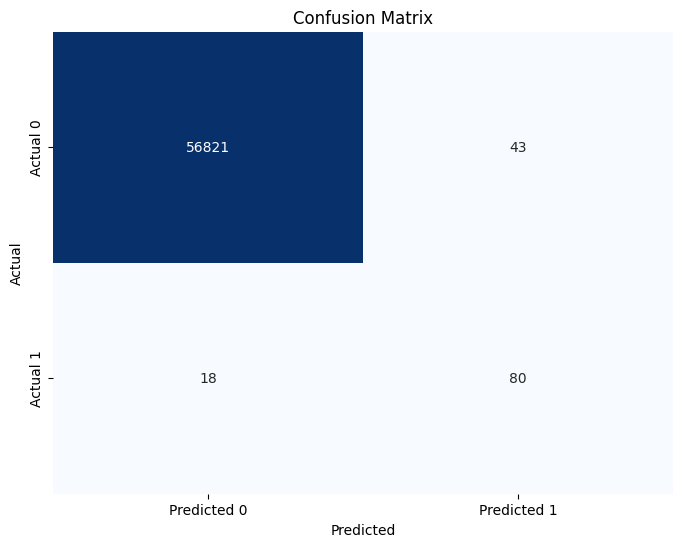

DNN model evaluation complete.


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions on the test set
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# 2. Evaluate the model on the test set
loss, accuracy, precision, recall = model.evaluate(X_test_scaled, y_test, verbose=0)

# Calculate F1-score separately using sklearn since Keras metrics might differ slightly
f1 = f1_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Set:")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# 3. Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("DNN model evaluation complete.")

El Accuracy es de 0.9989 (99.89%). Es una métrica engañosa. Como la gran mayoría de las transacciones son legítimas (clase 0), un modelo que simplemente diga "todo es normal" tendría un accuracy altísimo, pero sería inútil.

Recall (0.82): Es una métrica sólida. Significa que rl modelo es capaz de identificar el 82% de los fraudes reales. Logrando capturar a la gran mayoría de los "culpables".

Precision (0.65): Indica que cuando el modelo marca una transacción como fraude, tiene un 65% de probabilidad de tener razón. El otro 35% son "falsas alarmas" (transacciones legítimas bloqueadas por error).

F1-Score (0.72): Es el equilibrio entre las dos anteriores. Para un modelo de red neuronal inicial en un dataset tan desbalanceado, un 0.72 es un resultado bastante bueno.

Analisis Matriz

Verdaderos Negativos (TN): 56,821 Transacciones normales que el modelo clasificó correctamente como normales. Es el bloque más grande (azul oscuro).

Verdaderos Positivos (TP): 80 Fraudes reales que el modelo detectó con éxito.

Falsos Positivos (FP): 43 Transacciones legítimas que el modelo marcó erróneamente como fraude. Esto explica por qué la Precisión era del 65% ($80 / (80 + 43)$).

Falsos Negativos (FN): 18 Este es el número más crítico en seguridad. Son 18 fraudes que el modelo no detectó. Esto explica el Recall del 81.6% ($80 / (80 + 18)$).

# Task
Grafica el historial de entrenamiento del modelo, mostrando las curvas de pérdida y precisión (accuracy) para los conjuntos de entrenamiento y validación, utilizando el objeto `history`.

## Graficar el historial de entrenamiento

### Subtask:
Visualizar las curvas de pérdida y precisión (accuracy) tanto para el conjunto de entrenamiento como para el de validación, utilizando el objeto `history` devuelto por `model.fit()`.


**Reasoning**:
The user wants to visualize the training and validation loss and accuracy curves. I will generate a code block to plot these using `matplotlib.pyplot` as instructed, creating two subplots for loss and accuracy respectively, and adding appropriate labels, legends, and a title.



Dataset '/content/sample_data/creditcard.csv' cargado exitosamente para esta ejecución de celda.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Re-training the DNN model to define history object...
DNN model re-training complete, history object is now defined.


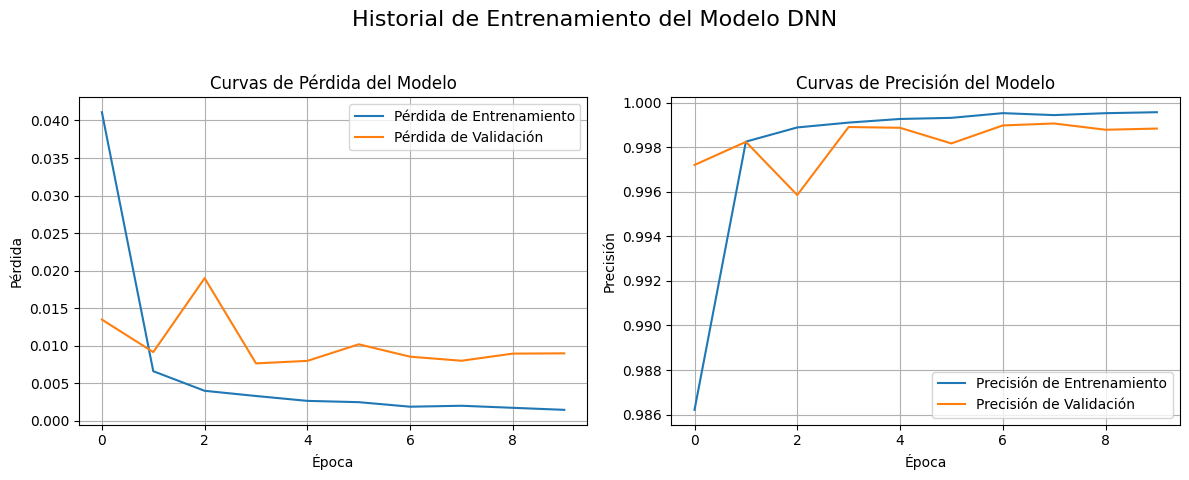

In [7]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import os

# --- START: Ensure df_fraude is loaded for this cell's execution ---
file_name = '/content/sample_data/creditcard.csv'
# Unconditionally load df_fraude to ensure it's available
df_fraude = pd.read_csv(file_name)
print(f"Dataset '{file_name}' cargado exitosamente para esta ejecución de celda.")
# --- END: Data loading ---

# --- START: Data preparation steps ---
# 1. Separate features (X) and target (y)
X = df_fraude.drop('Class', axis=1)
y = df_fraude['Class']

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Handle data imbalance (SMOTE)
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

# 4. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for consistency if needed later, or leave as numpy arrays
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_resampled.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
# --- END: Data preparation steps ---

# 1. Get the number of features from the scaled training data
input_shape = X_train_scaled.shape[1]

# 2. Initialize a sequential model
model = Sequential()

# 3. Add Dense layers
# Input layer and first hidden layer
model.add(Dense(units=64, activation='relu', input_shape=(input_shape,)))
# Second hidden layer
model.add(Dense(units=32, activation='relu'))
# Third hidden layer
model.add(Dense(units=16, activation='relu'))

# 4. Add the output layer for binary classification
model.add(Dense(units=1, activation='sigmoid'))

# 5. Compile the model
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Define training parameters
epochs = 10
batch_size = 256

print("\nRe-training the DNN model to define history object...")
history = model.fit(
    X_train_scaled,
    y_resampled,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test_scaled, y_test),
    verbose=0 # Suppress verbose output for re-training if not needed
)
print("DNN model re-training complete, history object is now defined.")

# 1. Create a figure with two subplots
plt.figure(figsize=(12, 5))

# 2. Plot training & validation loss values
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Curvas de Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# 3. Plot training & validation accuracy values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Curvas de Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Add a general title to the figure
plt.suptitle('Historial de Entrenamiento del Modelo DNN', fontsize=16)

# Ensure plots do not overlap and display the figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Curvas de Pérdida (Loss)**

La pérdida mide qué tan "equivocado" está el modelo. Lo ideal es que ambas líneas bajen y se estabilicen juntas.

Pérdida de Entrenamiento (Azul): Cae de forma casi perfecta y constante. Esto indica que el modelo tiene la capacidad necesaria para aprender los patrones del conjunto de datos balanceado con SMOTE.

Pérdida de Validación (Naranja): Es mucho más errática (con ese pico notable en la época 2). Sin embargo, después de la época 3 se estabiliza.

Diagnóstico: Al final de las 10 épocas, la brecha entre las dos líneas es pequeña. Esto sugiere que no hay un sobreajuste (overfitting) severo. El modelo ha generalizado bien.


**Curvas de Precisión (Accuracy)**

Entrenamiento vs. Validación: Mira cómo la precisión de entrenamiento termina ligeramente por encima de la de validación (cerca de 0.9995 vs 0.9988).

Estabilidad: Después de la época 4, las mejoras son marginales. Esto indica que el modelo ha alcanzado su punto de convergencia. Entrenarlo por 50 épocas más probablemente no mejoraría los resultados y solo aumentaría el riesgo de overfitting.